In [33]:
import os
import requests
import pandas as pd 
from dotenv import load_dotenv
from google.transit import gtfs_realtime_pb2
load_dotenv()

True

In [105]:
headers = {'Accept': 'application/json'}
response = requests.get("https://api-endpoint.mta.info/Dataservice/mtagtfsfeeds/nyct%2Fgtfs-si", headers)

feed = gtfs_realtime_pb2.FeedMessage()
if response.status_code == 200:
    feed.ParseFromString(response.content)
else:
    print(f"Error {response.status_code}: {response.text}")

In [123]:
trip_data = {}
trip_data_list = []
for fd in feed.entity:
    print(fd)
    trip_data_list.append(
        {
            "id": fd.id,
            "trip_id": fd.trip_update.trip.trip_id,
            "start_time": fd.trip_update.trip.start_time,
            "start_date": fd.trip_update.trip.start_date,
            "route_id": fd.trip_update.trip.route_id,
            "current_stop_sequence": fd.vehicle.current_stop_sequence or "NONE",
            "current_status": fd.vehicle.current_status or "NONE",
            "timestamp": fd.vehicle.timestamp or "NONE",
            "stop_id": fd.vehicle.stop_id or "NONE"
        }
    )



def return_data():
    return trip_data_list

return_data()


id: "000001SI"
trip_update {
  trip {
    trip_id: "110400_SI.N03R"
    start_time: "18:24:00"
    start_date: "20260520"
    route_id: "SI"
  }
}

id: "000002SI"
vehicle {
  trip {
    trip_id: "110400_SI.N03R"
    start_time: "18:24:00"
    start_date: "20260520"
    route_id: "SI"
  }
  current_stop_sequence: 4
  current_status: STOPPED_AT
  timestamp: 1779318321
  stop_id: "S15N"
}

id: "000003SI"
trip_update {
  trip {
    trip_id: "111100_SI.S07R"
    start_time: "18:31:30"
    start_date: "20260520"
    route_id: "SS"
  }
  stop_time_update {
    arrival {
      time: 1779321679
    }
    departure {
      time: 1779321679
    }
    stop_id: "S18S"
  }
  stop_time_update {
    arrival {
      time: 1779321750
    }
    departure {
      time: 1779321750
    }
    stop_id: "S17S"
  }
  stop_time_update {
    arrival {
      time: 1779321870
    }
    departure {
      time: 1779321870
    }
    stop_id: "S16S"
  }
  stop_time_update {
    arrival {
      time: 1779321990
    }
  

[{'id': '000001SI',
  'trip_id': '110400_SI.N03R',
  'start_time': '18:24:00',
  'start_date': '20260520',
  'route_id': 'SI',
  'current_stop_sequence': 'NONE',
  'current_status': 2,
  'timestamp': 'NONE',
  'stop_id': 'NONE'},
 {'id': '000002SI',
  'trip_id': '',
  'start_time': '',
  'start_date': '',
  'route_id': '',
  'current_stop_sequence': 4,
  'current_status': 1,
  'timestamp': 1779318321,
  'stop_id': 'S15N'},
 {'id': '000003SI',
  'trip_id': '111100_SI.S07R',
  'start_time': '18:31:30',
  'start_date': '20260520',
  'route_id': 'SS',
  'current_stop_sequence': 'NONE',
  'current_status': 2,
  'timestamp': 'NONE',
  'stop_id': 'NONE'},
 {'id': '000004SI',
  'trip_id': '',
  'start_time': '',
  'start_date': '',
  'route_id': '',
  'current_stop_sequence': 2,
  'current_status': 1,
  'timestamp': 1779321679,
  'stop_id': 'S18S'},
 {'id': '000005SI',
  'trip_id': '112100_SI.N03R',
  'start_time': '18:44:00',
  'start_date': '20260520',
  'route_id': 'SI',
  'current_stop_seq

In [12]:
import sys
import subprocess

# This forces Python to install the packages directly into the current Jupyter environment
subprocess.check_call([sys.executable, "-m", "pip", "install", "requests", "pandas", "matplotlib", "protobuf", "gtfs-realtime-bindings"])

Defaulting to user installation because normal site-packages is not writeable


You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


0

/Users/sasha/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


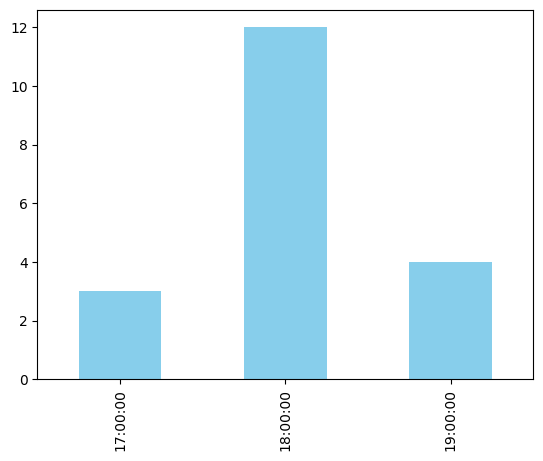

In [13]:
import requests, pandas as pd, matplotlib.pyplot as plt
from google.transit import gtfs_realtime_pb2

# 1. Fetch data & parse it directly
feed = gtfs_realtime_pb2.FeedMessage()
feed.ParseFromString(requests.get("https://api-endpoint.mta.info/Dataservice/mtagtfsfeeds/nyct%2Fgtfs-si").content)

# 2. Get hours, count them, and plot instantly
hours = [f.trip_update.trip.start_time[:2] + ":00:00" for f in feed.entity if f.HasField('trip_update')]
pd.Series(hours).value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.show()